# Appendix comparison overview

This notebook compares **our sample** against the published variability measurements from **MacLeod+2010** and **Stone+2021/2022** (matched-source analyses and diagnostic plots).

Before running the analysis cells, you must run: `setup_data --apendix`.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import astropy.units as u

from astropy.io import fits
from astropy.coordinates import SkyCoord

from qvc.hubble.hubble_utils import load_agn_data, match_radec, read_quasars_from_hdf5_flat
from qvc.light_curve.plotting_appendix import (
    plot_sigma_tau_identity_grid,
    plot_sigma_tau_style_comparison,
)

from qvc.hubble.cuts import (
    LOG_SIGMA_UV_MIN,
    LOG_SIGMA_UV_MAX,
    LOG_TAU_UV_RF_MIN,
    LOG_TAU_UV_RF_MAX,
)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False


In [2]:
AGN_H5 = "../results/data/apr21_0904pm_ba3c291_macleod.h5"
SPECTRA_FIT_CSV = ["../results/data/jaxqsofit_apr14a_chisq20_apr9a.csv"]
macleod_DIR = Path("../data/MacLeod2010")
BANDS = ["u", "g", "r", "i"]
BAND = "r"
MATCH_RADIUS_ARCSEC = 1.0

PLOT_PATH = "/tmp/qvc_macleod_compare_apr11a"
CUT_REPORT_PATH = "/tmp/qvc_macleod_compare_apr11a/cut_report.txt"

macleod_COLUMNS = [
    "SDR5ID",
    "ra",
    "dec",
    "redshift",
    "M_i",
    "mass_BH_Msun",
    "chi2_pdf",
    "log10_tau_days",
    "log10_sigma_mag_sqrt_yr",
    "log10_tau_lim_lo",
    "log10_tau_lim_hi",
    "log10_sig_lim_lo",
    "log10_sig_lim_hi",
    "edge_flag",
    "Plike",
    "Pnoise",
    "Pinf",
    "mu",
    "npts",
]


In [3]:
quasar_list = read_quasars_from_hdf5_flat(AGN_H5)
df_agn = pd.DataFrame(quasar_list)
df_agn['object_id'] = df_agn['object_id'].astype(str)
print(list(df_agn.keys()))


['LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'LOGLBOL_CORRECTED', 'LOGLBOL_CORRECTED_ERR', 'LOGLBOL_ERR', 'SN_MEDIAN_ALL', 'adf_any_pvalue_lt_0p05', 'adf_min_pvalue', 'adf_nobs_g', 'adf_nobs_i', 'adf_nobs_r', 'adf_nobs_u', 'adf_pvalue_g', 'adf_pvalue_i', 'adf_pvalue_r', 'adf_pvalue_u', 'adf_stat_g', 'adf_stat_i', 'adf_stat_r', 'adf_stat_u', 'adf_usedlag_g', 'adf_usedlag_i', 'adf_usedlag_r', 'adf_usedlag_u', 'adf_valid_g', 'adf_valid_i', 'adf_valid_r', 'adf_valid_u', 'alpha_high_ls', 'alpha_high_ls_err', 'amp_bc_g', 'amp_bc_g_err', 'amp_bc_i', 'amp_bc_i_err', 'amp_bc_r', 'amp_bc_r_err', 'amp_bc_u', 'amp_bc_u_err', 'amp_blr2_g', 'amp_blr2_g_err', 'amp_blr2_i', 'amp_blr2_i_err', 'amp_blr2_r', 'amp_blr2_r_err', 'amp_blr2_u', 'amp_blr2_u_err', 'amp_blr_g', 'amp_blr_g_err', 'amp_blr_i', 'amp_blr_i_err', 'amp_blr_r', 'amp_blr_r_err', 'amp_blr_u', 'amp_blr_u_err', 'amp_cont_g', 'amp_cont_g_err', 'amp_cont_i', 'amp_cont_i_err', 'amp_cont_r', 'amp_cont_r_err', 'amp_cont_u', 'amp_cont_u_err', 'bands_g

In [4]:

MACLEOD_YEAR_DAYS = 365.25

def read_macleod_band(band=BAND):
    path = macleod_DIR / f"s82drw_{band}.dat"
    df = pd.read_csv(path, comment="#", sep=r"\s+", header=None)
    df.columns = macleod_COLUMNS
    x_tau = pd.to_numeric(df["log10_tau_days"], errors="coerce").to_numpy(dtype=float)
    tau_lo = pd.to_numeric(df["log10_tau_lim_lo"], errors="coerce").to_numpy(dtype=float)
    tau_hi = pd.to_numeric(df["log10_tau_lim_hi"], errors="coerce").to_numpy(dtype=float)
    edge_flag = pd.to_numeric(df["edge_flag"], errors="coerce").to_numpy(dtype=float)
    xerr_low_tau = x_tau - tau_lo
    xerr_high_tau = tau_hi - x_tau
    valid_xerr_tau = (
        np.isfinite(xerr_low_tau) & np.isfinite(xerr_high_tau)
        & (xerr_low_tau >= 0.0) & (xerr_high_tau >= 0.0)
        & (tau_lo < tau_hi) & (tau_lo < x_tau) & (x_tau < tau_hi)
        & (edge_flag == 0)
    )
    valid_large_tau_hi = np.isfinite(xerr_high_tau) & np.isfinite(x_tau) #& (xerr_high_tau < 0.6 * x_tau)
    df = df.loc[valid_xerr_tau & valid_large_tau_hi].copy()
    df["band"] = band
    return df


def build_band_comparison(df_ours, band=BAND, max_sep_arcsec=MATCH_RADIUS_ARCSEC):
    macleod = read_macleod_band(band)
    matched, unmatched = match_radec(
        df_ours,
        macleod,
        populate_cols=[
            "SDR5ID",
            "redshift",
            "log10_tau_days",
            "log10_tau_lim_lo",
            "log10_tau_lim_hi",
            "log10_sigma_mag_sqrt_yr",
            "log10_sig_lim_lo",
            "log10_sig_lim_hi",
            "npts",
            "edge_flag",
            "chi2_pdf",
            "Plike",
            "Pnoise",
            "Pinf",
        ],
        max_sep_arcsec=max_sep_arcsec,
        add_prefix=True,
    )
    matched = matched[matched["matched_idx_b"] >= 0].copy()
    matched = matched.rename(
        columns={
            "matched_SDR5ID": f"macleod_SDR5ID_{band}",
            "matched_redshift": f"macleod_redshift_{band}",
            "matched_log10_tau_days": f"macleod_tau_obs_{band}",
            "matched_log10_tau_lim_lo": f"macleod_tau_obs_lo_{band}",
            "matched_log10_tau_lim_hi": f"macleod_tau_obs_hi_{band}",
            "matched_log10_sigma_mag_sqrt_yr": f"macleod_log_sigma_hat_catalog_{band}",
            "matched_log10_sig_lim_lo": f"macleod_sigma_obs_lo_{band}",
            "matched_log10_sig_lim_hi": f"macleod_sigma_obs_hi_{band}",
            "matched_npts": f"macleod_npts_{band}",
            "matched_edge_flag": f"macleod_edge_flag_{band}",
            "matched_chi2_pdf": f"macleod_chi2_pdf_{band}",
            "matched_Plike": f"macleod_Plike_{band}",
            "matched_Pnoise": f"macleod_Pnoise_{band}",
            "matched_Pinf": f"macleod_Pinf_{band}",
        }
    )
    macleod_redshift = pd.to_numeric(matched[f"macleod_redshift_{band}"], errors='coerce')
    redshift_log_factor = np.log10(1.0 + macleod_redshift.to_numpy(dtype=float))
    matched[f"macleod_sigma_{band}"] = (
        matched[f"macleod_log_sigma_hat_catalog_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_lo_{band}"] = (
        matched[f"macleod_sigma_obs_lo_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_hi_{band}"] = (
        matched[f"macleod_sigma_obs_hi_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_tau_{band}"] = matched[f"macleod_tau_obs_{band}"]
    matched[f"macleod_tau_lo_{band}"] = matched[f"macleod_tau_obs_lo_{band}"]
    matched[f"macleod_tau_hi_{band}"] = matched[f"macleod_tau_obs_hi_{band}"]
    matched[f"ours_sigma_{band}"] = matched[f"log_sigma_band_{band}"]
    matched[f"ours_sigma_{band}_err"] = matched[f"log_sigma_band_{band}_err"]
    matched[f"ours_tau_{band}"] = matched[f"log_tau_band_{band}_RF"]
    matched[f"ours_tau_{band}_err"] = matched[f"log_tau_band_{band}_RF_err"]
    matched[f"delta_log_sigma_{band}"] = matched[f"ours_sigma_{band}"] - matched[f"macleod_sigma_{band}"]
    matched[f"delta_log_tau_{band}"] = matched[f"ours_tau_{band}"] - matched[f"macleod_tau_{band}"]

    macleod_edge_flag = pd.to_numeric(matched[f"macleod_edge_flag_{band}"], errors='coerce')
    macleod_Plike = pd.to_numeric(matched[f"macleod_Plike_{band}"], errors='coerce')
    macleod_Pnoise = pd.to_numeric(matched[f"macleod_Pnoise_{band}"], errors='coerce')
    macleod_Pinf = pd.to_numeric(matched[f"macleod_Pinf_{band}"], errors='coerce')
    m10_quality_mask = (
        (macleod_edge_flag == 0)
        & ((macleod_Plike - macleod_Pnoise) > 2.0)
        & ((macleod_Plike - macleod_Pinf) > 0.05)
    )
    finite_range_mask = (
        matched[f"macleod_tau_{band}"].between(LOG_TAU_UV_RF_MIN, LOG_TAU_UV_RF_MAX)
        & matched[f"macleod_sigma_{band}"].between(LOG_SIGMA_UV_MIN, LOG_SIGMA_UV_MAX)
    )
    macleod_cut_mask =  finite_range_mask & m10_quality_mask
    matched_cut = matched[macleod_cut_mask].copy()
    return matched, matched_cut, macleod, unmatched


matched_by_band_all = {}
matched_by_band_subcut = {}
macleod_by_band = {}
unmatched_by_band = {}
for band in BANDS:
    matched_all, matched_subcut, macleod_band_df, unmatched_macleod_band = build_band_comparison(df_agn, band=band)
    matched_by_band_all[band] = matched_all
    matched_by_band_subcut[band] = matched_subcut
    macleod_by_band[band] = macleod_band_df
    unmatched_by_band[band] = unmatched_macleod_band

matched_r_all = matched_by_band_all["r"]
matched_r_subcut = matched_by_band_subcut["r"]
macleod_r = macleod_by_band["r"]
unmatched_object_ids = unmatched_by_band["r"]

print(f"MacLeod+2010 r-band rows: {len(macleod_r):,}")
print(f"Matched r-band rows: {len(matched_r_all):,}")
print(f"Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: {len(matched_r_subcut):,}")
print(f"Median match separation (all matched): {np.nanmedian(matched_r_all['matched_sep_arcsec']) if len(matched_r_all) else np.nan:.4f} arcsec")
for band in BANDS:
    print(
        f"{band}-band matched: {len(matched_by_band_all[band]):,} total, "
        f"{len(matched_by_band_subcut[band]):,} after MacLeod+2010 quality + sigma/tau cuts"
    )


MacLeod+2010 r-band rows: 7,661
Matched r-band rows: 7,582
Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: 6,548
Median match separation (all matched): 0.0332 arcsec
u-band matched: 7,924 total, 6,755 after MacLeod+2010 quality + sigma/tau cuts
g-band matched: 7,946 total, 7,151 after MacLeod+2010 quality + sigma/tau cuts
r-band matched: 7,582 total, 6,548 after MacLeod+2010 quality + sigma/tau cuts
i-band matched: 7,605 total, 6,167 after MacLeod+2010 quality + sigma/tau cuts


In [5]:
summary_rows = [
    {
        "sample": "ours matched (M10 quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['ours_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['ours_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['ours_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['ours_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "M10 r matched (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['macleod_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['macleod_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['macleod_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['macleod_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "delta this work-M10 (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['delta_log_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['delta_log_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['delta_log_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['delta_log_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

display(
    matched_r_all[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'ours_tau_r',
        'macleod_SDR5ID_r', 'macleod_redshift_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r', 'macleod_tau_r',
        'delta_log_sigma_r', 'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head()
)


,sample,n,sigma_median,sigma_std,tau_median,tau_std
0,ours matched (M10 quality cut),6548,-0.957853,0.192722,2.626130,0.353897
1,M10 r matched (quality cut),6548,-0.850766,0.220692,2.782775,0.456507
2,delta this work-M10 (quality cut),6548,-0.107410,0.195700,-0.166759,0.495907


,object_id,ra,dec,z,ours_sigma_r,ours_tau_r,macleod_SDR5ID_r,macleod_redshift_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,macleod_tau_r,delta_log_sigma_r,delta_log_tau_r,matched_sep_arcsec
0,1384142,58.588627,-0.527031,2.445898,-1.004595,2.741522,8628,2.4374,-1.05034,-0.78886,3.38658,-0.215734,-0.645058,0.018000
1,1384144,58.545729,-0.630169,1.885438,-1.111366,2.220044,8625,1.8736,-0.707317,-0.925972,2.42631,-0.185394,-0.206266,0.008049
2,1384145,58.515703,-0.988505,2.740166,-0.894242,2.732736,8624,2.7488,-0.598894,-0.726449,2.60851,-0.167793,0.124226,0.025957
3,1384146,58.374480,-0.724232,3.689721,-1.013003,2.635157,8618,3.6774,-0.964126,-1.065781,2.66031,0.052778,-0.025153,0.011383
4,1384147,58.339221,-0.559442,1.834780,-0.581846,3.130005,8616,1.8253,-0.947577,-0.302232,4.15431,-0.279614,-1.024305,0.010799


In [6]:
TOP_N = 10

print(f'Top {TOP_N} |delta_log_sigma_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_sigma_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r',
        'delta_log_sigma_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)

print(f'Top {TOP_N} |delta_log_tau_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_tau_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_tau_r', 'macleod_tau_r',
        'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)


Top 10 |delta_log_sigma_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_sigma_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,delta_log_sigma_r,matched_sep_arcsec
3630,1419335,20.300589,-0.510288,1.658067,-1.136630,-0.812109,0.075141,-1.211771,0.078308
6854,1456023,339.070157,0.785930,1.643910,-1.078607,-0.788294,0.021741,-1.100348,0.015273
2915,1408296,28.379216,-0.057264,1.909079,-1.175721,-0.980491,-0.103681,-1.07204,0.021898
8189,1467543,315.454739,-1.146889,0.602939,-0.954352,-0.620695,0.114265,-1.068617,0.012978
7196,1458516,334.366563,0.969031,2.166364,-1.045188,-0.73345,0.01446,-1.059648,0.058040
6327,1451344,348.127891,-0.023718,1.690365,-1.040731,-0.775685,0.012345,-1.053076,0.029024
4255,1429146,12.507547,0.438921,1.948263,-1.254452,-0.994465,-0.205505,-1.048947,0.086709
5762,1447475,355.291675,-0.699756,3.829784,-1.642220,-0.991704,-0.602769,-1.039451,0.052093
4165,1427895,13.583284,0.457762,2.511390,-0.355406,-1.23028,-1.363365,1.00796,0.002566
2523,1402965,32.403825,-0.371192,2.395097,-1.181109,-0.955528,-0.175678,-1.005431,0.053819


Top 10 |delta_log_tau_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_tau_r,macleod_tau_r,delta_log_tau_r,matched_sep_arcsec
7886,1463447,324.995627,1.004498,2.004824,3.190435,-1.4494,4.639835,0.032594
7481,1460382,330.785651,-1.051628,1.986902,2.841927,-1.448,4.289927,0.030544
4164,1427891,13.589280,-1.156030,5.047107,2.584174,-1.44872,4.032894,0.101124
1385,1387557,43.085604,0.459747,1.686798,2.416466,-1.52566,3.942126,0.036178
4547,1433572,9.218327,-0.815901,2.661460,2.372684,-1.14985,3.522534,0.140030
4686,1435332,7.877144,0.332837,1.794989,2.052650,-1.43235,3.485,0.011384
2565,1403466,32.052696,0.698832,0.694268,2.736987,-0.522315,3.259302,0.026175
8602,1467998,309.560630,-0.427481,2.699760,3.256812,0.044101,3.212711,0.029023
92,1384242,56.388660,-0.933066,2.743512,3.250971,0.139056,3.111915,0.030758
5485,1445768,358.500376,0.961348,1.247876,2.562128,-0.44186,3.003988,0.038768


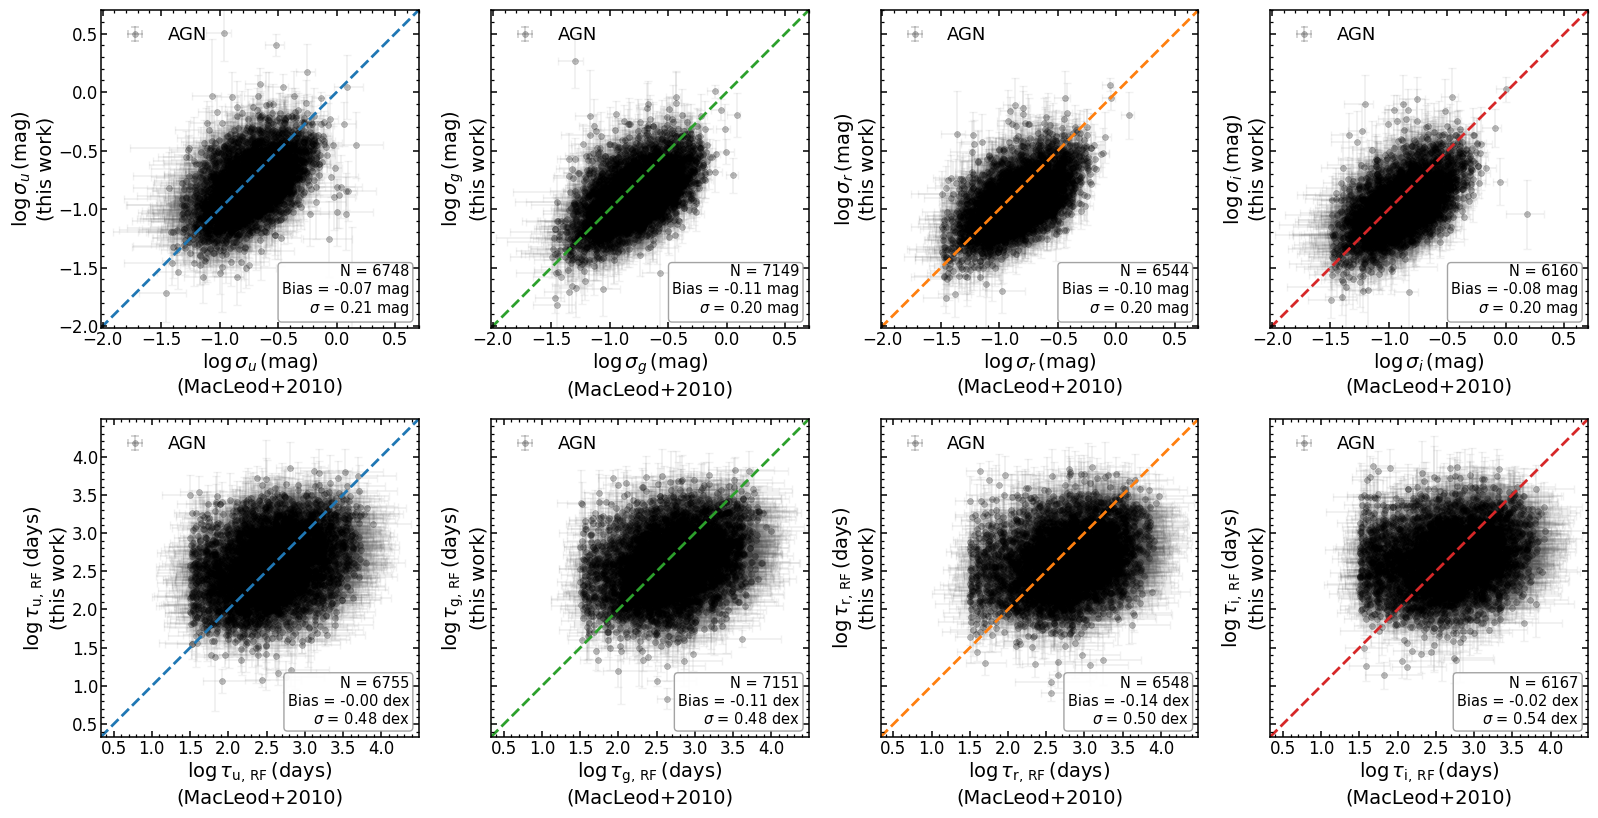

In [7]:
macleod_sigma_keys = {
    'x': 'macleod_sigma_{band}',
    'y': 'ours_sigma_{band}',
    'xerr': ('macleod_sigma_lo_{band}', 'macleod_sigma_hi_{band}'),
    'xerr_mode': 'bounds',
    'yerr': 'ours_sigma_{band}_err',
    'xlabel': r'$\log\!\,\sigma_<<band>>\,(\mathrm{mag})$' + '\n(MacLeod+2010)',
    'ylabel': r'$\log\!\,\sigma_<<band>>\,(\mathrm{mag})$' + '\n(this work)',
}

macleod_tau_keys = {
    'x': 'macleod_tau_{band}',
    'y': 'ours_tau_{band}',
    'xerr': ('macleod_tau_lo_{band}', 'macleod_tau_hi_{band}'),
    'xerr_mode': 'bounds',
    'yerr': 'ours_tau_{band}_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(MacLeod+2010)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}

_ = plot_sigma_tau_identity_grid(
    matched_by_band_subcut,
    macleod_sigma_keys,
    macleod_tau_keys,
    bands=('u', 'g', 'r', 'i'),
    output_path='../plots/hubble/diagnostics/tau_identity_this_work_vs_MacLeod2010_ugri_MacLeod2010_tau_cut.pdf',
    style={'point_alpha': 0.25, 'error_alpha': 0.08, 'rasterized': False},
)
plt.show()


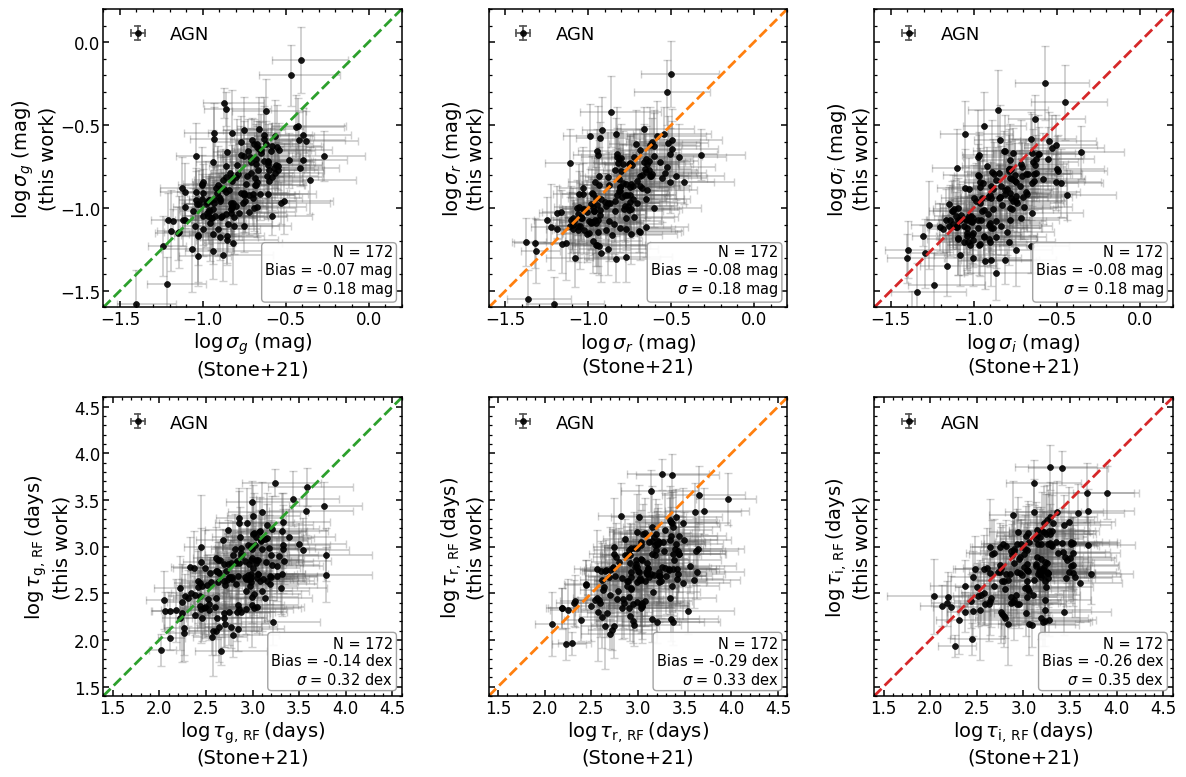

In [8]:
sigma_keys_raw = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(this work)',
}

tau_keys_raw = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}

# Load Stone+21 data from FITS and match onto the S82 object ids used by this work
stone_fits_path = Path('../data/Stone2021/TotalDat.fits')
with fits.open(stone_fits_path, memmap=False) as hdul:
    stone_data = hdul[1].data

stone_rows = []
for i in range(len(stone_data)):
    row = {
        'stone_DBID': stone_data['DBID'][i],
        'stone_RA': stone_data['RA'][i],
        'stone_DEC': stone_data['DEC'][i],
        'stone_Z': stone_data['Z'][i],
    }
    for band in ('g', 'r', 'i'):
        row |= {
            f'stone_log_SIGMA_{band}': stone_data[f'log_SIGMA_{band}'][i],
            f'stone_log_SIGMA_{band}_ERR_L': stone_data[f'log_SIGMA_{band}_ERR_L'][i],
            f'stone_log_SIGMA_{band}_ERR_U': stone_data[f'log_SIGMA_{band}_ERR_U'][i],
            f'stone_log_TAU_REST_{band}': stone_data[f'log_TAU_REST_{band}'][i],
            f'stone_log_TAU_REST_{band}_ERR_L': stone_data[f'log_TAU_REST_{band}_ERR_L'][i],
            f'stone_log_TAU_REST_{band}_ERR_U': stone_data[f'log_TAU_REST_{band}_ERR_U'][i],
        }
    stone_rows.append(row)

stone_df = pd.DataFrame(stone_rows)

cat = pd.read_parquet('../data/S82/Catalog.parquet').reset_index()
stone_coords = SkyCoord(ra=stone_df['stone_RA'].to_numpy() * u.deg, dec=stone_df['stone_DEC'].to_numpy() * u.deg)
cat_coords = SkyCoord(ra=cat['RA'].to_numpy() * u.deg, dec=cat['DEC'].to_numpy() * u.deg)
idx, d2d, _ = stone_coords.match_to_catalog_sky(cat_coords)
match_mask = d2d < 1.0 * u.arcsec

stone_df = stone_df.loc[match_mask].copy()
stone_df['object_id'] = cat.iloc[idx[match_mask]]['objectId'].astype(str).to_numpy()
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

os.makedirs("figures/appendix/stone_tests", exist_ok=True)
merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_sigma_tau_identity_grid(
    merged_agn_stone,
    sigma_keys_raw,
    tau_keys_raw,
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    output_path='figures/appendix/stone_fitted_band_fields.pdf',
    style={'point_alpha': 0.9, 'error_alpha': 0.28, 'rasterized': False},
    sigma_limits=(-1.6, 0.2),
    tau_limits=(1.4, 4.6),
)

stone_r_overlay = merged_agn_stone.rename(columns={
    'stone_log_SIGMA_r': 'stone_sigma_r',
    'stone_log_TAU_REST_r': 'stone_tau_r',
}).copy()


Suberlak+2021 r-band rows: 8,516
Rows with finite coordinates: 8,485
Matched r-band rows: 7,980
Rows passing log10sigmahat/log10tau > -10: 8,469
Rows passing Plike-Pnoise > 2: 8,423
Rows passing Plike-Pinf > 0.05: 6,436
Rows passing edge == 0: 7,136
Rows passing tauEXP_sdss-ps1 > 2: 8,485
Rows passing log10(tauEXP_sdss-ps1 / (1 + REDSHIFT)) >= 1.5: 7,718
Rows passing full Suberlak/M10 quality mask: 6,361
Matched r-band rows after Suberlak/M10 quality + tau cuts: 6,072
Median match separation (all matched): 0.0230 arcsec


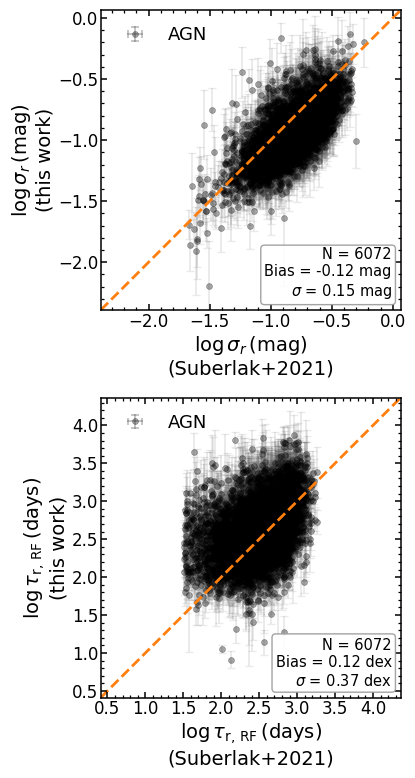

In [9]:
suberlak_path = Path('../data/190807_Celerite_real_Jeff1_Shen2008-2011_s82drw_r.txt')
suberlak_raw = pd.read_csv(suberlak_path, comment='#', sep=r'\s+')
for col in [
    'RA',
    'DEC',
    'redshift_1',
    'sigmaEXP_sdss-ps1',
    'tauEXP_sdss-ps1',
]:
    suberlak_raw[col] = pd.to_numeric(suberlak_raw[col], errors='coerce')
suberlak_valid = suberlak_raw.loc[
    np.isfinite(suberlak_raw['RA'])
    & np.isfinite(suberlak_raw['DEC'])
    & np.isfinite(suberlak_raw['REDSHIFT'])
    & np.isfinite(suberlak_raw['sigmaEXP_sdss-ps1'])
    & np.isfinite(suberlak_raw['tauEXP_sdss-ps1'])
    & np.isfinite(suberlak_raw['log10sigmahat'])
    & np.isfinite(suberlak_raw['log10tau'])
    & np.isfinite(suberlak_raw['Plike'])
    & np.isfinite(suberlak_raw['Pnoise'])
    & np.isfinite(suberlak_raw['Pinf'])
    & np.isfinite(suberlak_raw['edge'])
    & (suberlak_raw['sigmaEXP_sdss-ps1'] > 0.0)
    & (suberlak_raw['tauEXP_sdss-ps1'] > 2.0)
    & ((1.0 + suberlak_raw['REDSHIFT']) > 0.0)
].copy()
suberlak_valid['m1_drw_bounds'] = (
    (suberlak_valid['log10sigmahat'] > -10.0)
    & (suberlak_valid['log10tau'] > -10.0)
)
suberlak_valid['m2_plike_pnoise'] = (
    suberlak_valid['Plike'] - suberlak_valid['Pnoise'] > 2.0
)
suberlak_valid['m3_plike_pinf'] = (
    suberlak_valid['Plike'] - suberlak_valid['Pinf'] > 0.05
)
suberlak_valid['m4_edge'] = suberlak_valid['edge'] == 0
suberlak_valid['m5_tauexp_floor'] = suberlak_valid['tauEXP_sdss-ps1'] > 2.0
suberlak_valid['suberlak_quality_mask'] = (
    suberlak_valid['m1_drw_bounds']
    & suberlak_valid['m2_plike_pnoise']
    & suberlak_valid['m3_plike_pinf']
    & suberlak_valid['m4_edge']
    & suberlak_valid['m5_tauexp_floor']
)

suberlak_coords = SkyCoord(
    ra=suberlak_valid['RA'].to_numpy(dtype=float) * u.deg,
    dec=suberlak_valid['DEC'].to_numpy(dtype=float) * u.deg,
)
agn_coords = SkyCoord(
    ra=pd.to_numeric(df_agn['ra'], errors='coerce').to_numpy(dtype=float) * u.deg,
    dec=pd.to_numeric(df_agn['dec'], errors='coerce').to_numpy(dtype=float) * u.deg,
)
idx, d2d, _ = suberlak_coords.match_to_catalog_sky(agn_coords)
match_mask = d2d < MATCH_RADIUS_ARCSEC * u.arcsec

suberlak_matched = suberlak_valid.loc[match_mask].copy().reset_index(drop=True)
suberlak_matched['matched_sep_arcsec'] = d2d.arcsec[match_mask]
matched_agn = df_agn.iloc[idx[match_mask]].copy().reset_index(drop=True)
suberlak_matched['object_id'] = matched_agn['object_id'].astype(str).to_numpy()

suberlak_plot_df = pd.concat(
    [suberlak_matched.reset_index(drop=True), matched_agn.reset_index(drop=True)],
    axis=1,
)
suberlak_plot_df = suberlak_plot_df.loc[:, ~suberlak_plot_df.columns.duplicated()].copy()

suberlak_plot_df['suberlak_sigma_r'] = np.log10(pd.to_numeric(suberlak_plot_df['sigmaEXP_sdss-ps1'], errors='coerce'))
suberlak_plot_df['suberlak_tau_r'] = np.log10(
    pd.to_numeric(suberlak_plot_df['tauEXP_sdss-ps1'], errors='coerce')
    / (1.0 + pd.to_numeric(suberlak_plot_df['REDSHIFT'], errors='coerce'))
)
suberlak_plot_df['m6_log_tau_rf_floor'] = suberlak_plot_df['suberlak_tau_r'] >= 1.5
suberlak_plot_df['ours_sigma_r'] = pd.to_numeric(suberlak_plot_df['log_sigma_band_r'], errors='coerce')
suberlak_plot_df['ours_sigma_r_err'] = pd.to_numeric(suberlak_plot_df['log_sigma_band_r_err'], errors='coerce')
suberlak_plot_df['ours_tau_r'] = pd.to_numeric(suberlak_plot_df['log_tau_band_r_RF'], errors='coerce')
suberlak_plot_df['ours_tau_r_err'] = pd.to_numeric(suberlak_plot_df['log_tau_band_r_RF_err'], errors='coerce')

suberlak_cut_df = suberlak_plot_df.loc[
    suberlak_plot_df['suberlak_quality_mask']
    & suberlak_plot_df['m6_log_tau_rf_floor']
].copy()

print(f'Suberlak+2021 r-band rows: {len(suberlak_raw):,}')
print(f'Rows with finite coordinates: {len(suberlak_valid):,}')
print(f'Matched r-band rows: {len(suberlak_plot_df):,}')
print(f'Rows passing log10sigmahat/log10tau > -10: {int(suberlak_valid["m1_drw_bounds"].sum()):,}')
print(f'Rows passing Plike-Pnoise > 2: {int(suberlak_valid["m2_plike_pnoise"].sum()):,}')
print(f'Rows passing Plike-Pinf > 0.05: {int(suberlak_valid["m3_plike_pinf"].sum()):,}')
print(f'Rows passing edge == 0: {int(suberlak_valid["m4_edge"].sum()):,}')
print(f'Rows passing tauEXP_sdss-ps1 > 2: {int(suberlak_valid["m5_tauexp_floor"].sum()):,}')
print(f'Rows passing log10(tauEXP_sdss-ps1 / (1 + REDSHIFT)) >= 1.5: {int(suberlak_plot_df["m6_log_tau_rf_floor"].sum()):,}')
print(f'Rows passing full Suberlak/M10 quality mask: {int(suberlak_valid["suberlak_quality_mask"].sum()):,}')
print(f'Matched r-band rows after Suberlak/M10 quality + tau cuts: {len(suberlak_cut_df):,}')
print(
    'Median match separation (all matched): '
    f"{np.nanmedian(suberlak_plot_df['matched_sep_arcsec']) if len(suberlak_plot_df) else np.nan:.4f} arcsec"
)

suberlak_sigma_keys = {
    'x': 'suberlak_sigma_r',
    'y': 'ours_sigma_r',
    'yerr': 'ours_sigma_r_err',
    'xlabel': r'$\log\!\,\sigma_r\,(\mathrm{mag})$' + '\n(Suberlak+2021)',
    'ylabel': r'$\log\!\,\sigma_r\,(\mathrm{mag})$' + '\n(this work)',
}
suberlak_tau_keys = {
    'x': 'suberlak_tau_r',
    'y': 'ours_tau_r',
    'yerr': 'ours_tau_r_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{r},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(Suberlak+2021)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{r},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}

os.makedirs('../plots/hubble/diagnostics', exist_ok=True)
_ = plot_sigma_tau_identity_grid(
    suberlak_cut_df,
    suberlak_sigma_keys,
    suberlak_tau_keys,
    bands=('r',),
    figsize=(4.6, 7.6),
    output_path='../plots/hubble/diagnostics/suberlak_identity_this_work_vs_Suberlak2021_r_quality_cut.pdf',
    style={'point_alpha': 0.35, 'error_alpha': 0.12, 'rasterized': False},
)


/home/dutra/dev/qvc2/src/qvc/light_curve/plotting_appendix.py:687: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


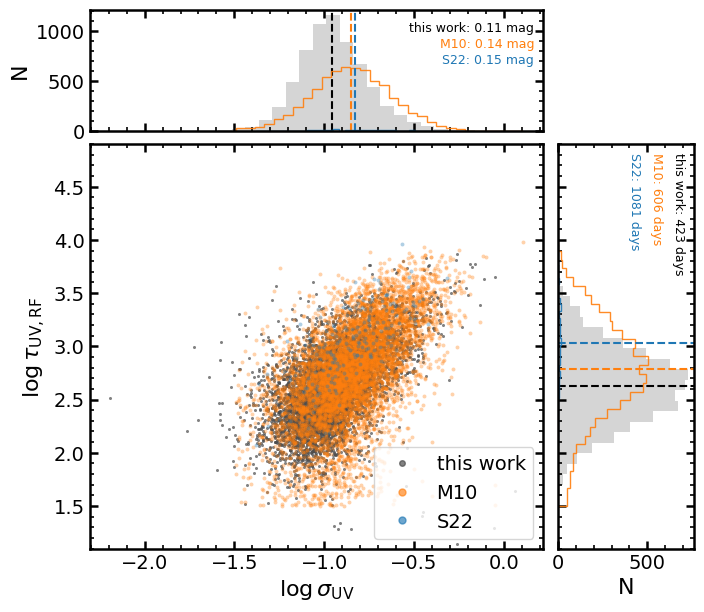

In [10]:
_ = plot_sigma_tau_style_comparison(
    matched_r_subcut,
    matched_r_subcut,
    title=None,
    comparison_overlays=[
        {
            'dataframe': matched_r_subcut,
            'sigma_col': 'macleod_sigma_r',
            'tau_col': 'macleod_tau_r',
            'label': 'M10',
            'color': 'tab:orange',
        },
        {
            'dataframe': stone_r_overlay,
            'sigma_col': 'stone_sigma_r',
            'tau_col': 'stone_tau_r',
            'label': 'S22',
            'color': 'tab:blue',
        },
    ],
)
plt.savefig("../plots/hubble/diagnostics/sigma_tau_comparison_this_work_vs_MacLeod2010_Stone2022_r.pdf", dpi=300)
plt.show()


In [11]:
suberlak_raw = pd.read_csv(suberlak_path, comment='#', sep=r'\s+')
suberlak_raw = suberlak_raw.rename(columns={
    'SDR5ID_2': 'SDR5ID',
    'ra_2': 'ra',
    'dec_2': 'dec',
    'redshift_2': 'redshift',
    'M_i_2': 'M_i',
    'mass_BH_2': 'mass_BH',
    'log10tau': 'log10_tau_days',
    'log10sigmahat': 'log10_sigma_mag_sqrt_yr',
    'log10tau_lim_lo': 'log10_tau_lim_lo',
    'log10tau_lim_hi': 'log10_tau_lim_hi',
    'log10sigmahat_lim_lo': 'log10_sig_lim_lo',
    'log10sigmahat_lim_hi': 'log10_sig_lim_hi',
    'edge': 'edge_flag',
    'Npts': 'npts',
})

In [12]:
suberlak_raw.keys()

Index(['lcname', 'length_sdss', 'sigmaEXP_sdss', 'sigmaMAP_sdss',
       'tauEXP_sdss', 'tauMAP_sdss', 'length_sdss-ps1', 'sigmaEXP_sdss-ps1',
       'sigmaMAP_sdss-ps1', 'tauEXP_sdss-ps1', 'tauMAP_sdss-ps1', 'dbID',
       'ra_1', 'dec_1', 'SDR5ID_1', 'M_i_1', 'M_i_corr', 'redshift_1',
       'mass_BH_1', 'Lbol', 'u', 'g', 'r', 'i', 'z', 'Au', 'SDSS_NAME', 'RA',
       'DEC', 'REDSHIFT', 'LOGLBOL', 'LOGBH', 'LOGBH_ERR', 'LOGEDD_RATIO',
       'MI_Z2', 'd2d_chelsea', 'SDR5ID', 'ra', 'dec', 'redshift', 'M_i',
       'mass_BH', 'chi2_pdf', 'log10_tau_days', 'log10_sigma_mag_sqrt_yr',
       'log10_tau_lim_lo', 'log10_tau_lim_hi', 'log10_sig_lim_lo',
       'log10_sig_lim_hi', 'edge_flag', 'Plike', 'Pnoise', 'Pinf', 'mu',
       'npts', 'SFinf', 'lambdaRF'],
      dtype='object')